In [1]:
pip install transformer_lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.7/977.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 127.3 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=f35774609963df243082b838bed38dc57f3f462a37927243edc3736b10045415
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
import random
from pathlib import Path
from itertools import product
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer

torch.manual_seed(42)
random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level2IOI")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Using device: cuda


Load model

In [3]:
model = HookedTransformer.from_pretrained(
    "gpt2",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
)
model.cfg.use_attn_result = True
model.eval()
model.to(device)

print(f"Layers: {model.cfg.n_layers}  Heads: {model.cfg.n_heads}  d_model: {model.cfg.d_model}")
print(f"use_attn_result: {model.cfg.use_attn_result}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
Layers: 12  Heads: 12  d_model: 768
use_attn_result: True


Build the IOI dataset

Following the paper exactly: pIOI uses two names (IO and S), pABC uses three unrelated random names. The paper uses 15 templates in both ABBA and BABA order.

In [4]:
NAMES = [
    "Mary", "John", "Alice", "Bob", "Emma", "Frank", "Grace", "Henry",
    "Iris", "Jack", "Kate", "Liam", "Mia", "Noah", "Olivia", "Paul",
    "Rose", "Sam", "Tina", "Victor", "Wendy", "Anna", "Brian", "Clara",
    "Elena", "Felix", "Gina", "Harry", "Jake", "Luna", "Mark", "Nina",
    "Oscar", "Pam", "Ray", "Sara", "Tom", "Vera", "Will", "Zoe"
]

PLACES  = ["store", "school", "park", "office", "market", "gym",
            "beach", "hotel", "library", "theater", "hospital", "mall"]

OBJECTS = ["drink", "book", "ball", "bag", "gift", "key",
            "pen", "hat", "ring", "card", "toy", "cup"]

# All templates use [IO] and [S] explicitly — no ambiguity
# [S] is the subject (appears twice), [IO] is the indirect object (predicted)
# These are the paper's BABA + ABBA templates translated to unambiguous notation
TEMPLATES = [
    # BABA: IO appears first in the clause, S appears twice
    "Then, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] were working at the [PLACE]. [S] decided to give a [OBJECT] to",
    "Then, [IO] and [S] were thinking about going to the [PLACE]. [S] wanted to give a [OBJECT] to",
    "After [IO] and [S] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [IO] and [S] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [IO] and [S] were working at the [PLACE], [S] gave a [OBJECT] to",
    "While [IO] and [S] were commuting to the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [IO] and [S] went to had a [OBJECT]. [S] gave it to",
    "Friends [IO] and [S] found a [OBJECT] at the [PLACE]. [S] gave it to",
    # ABBA: S appears first in the clause, S appears twice
    "Then, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [S] and [IO] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "After [S] and [IO] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [S] and [IO] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [S] and [IO] were working at the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [S] and [IO] went to had a [OBJECT]. [S] gave it to",
]

def build_dataset(N, use_abc=False, seed=42):
    rng = random.Random(seed)
    dataset = []
    for i in range(N):
        template = rng.choice(TEMPLATES)
        place    = rng.choice(PLACES)
        obj      = rng.choice(OBJECTS)

        if use_abc:
            # pABC: three unrelated names, no duplication signal
            a, b, c = rng.sample(NAMES, 3)
            prompt = (template
                        .replace("[IO]", a)
                        .replace("[S]", b, 1)   # first [S] → b
                        .replace("[S]", c)       # second [S] → c
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))
            io_name, s_name = a, b
        else:
            io_name, s_name = rng.sample(NAMES, 2)
            prompt = (template
                        .replace("[IO]", io_name)
                        .replace("[S]", s_name)
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))

        dataset.append({"prompt": prompt, "io": io_name,"s": s_name, "template": template})
    return dataset

N = 200
ioi_data = build_dataset(N, use_abc=False, seed=42)
abc_data = build_dataset(N, use_abc=True,  seed=42)

# Sanity check
ex = ioi_data[0]
print(f"IOI: {ex['prompt']!r}")
print(f"     IO={ex['io']}  S={ex['s']}: model should predict '{ex['io']}'")
ex2 = ioi_data[1]
print(f"IOI: {ex2['prompt']!r}")
print(f"     IO={ex2['io']}  S={ex2['s']}: model should predict '{ex2['io']}'")
print(f"\nABC: {abc_data[0]['prompt']!r}")

IOI: 'Then, Sam and Paul were thinking about going to the store. Paul wanted to give a cup to'
     IO=Sam  S=Paul: model should predict 'Sam'
IOI: 'While Grace and Ray were commuting to the park, Ray gave a cup to'
     IO=Grace  S=Ray: model should predict 'Grace'

ABC: 'Then, Sam and Paul were thinking about going to the store. Olivia wanted to give a cup to'


Tokenise and verify single-token names

In [5]:
def tokenize_dataset(data, model):
    valid = []
    for ex in data:
        io_tok = model.to_tokens(" " + ex["io"], prepend_bos=False).squeeze()
        s_tok  = model.to_tokens(" " + ex["s"],  prepend_bos=False).squeeze()
        if io_tok.ndim == 0 and s_tok.ndim == 0:
            valid.append({**ex, "io_tok": io_tok.item(), "s_tok":  s_tok.item()})
    return valid

ioi_valid = tokenize_dataset(ioi_data, model)
abc_valid  = tokenize_dataset(abc_data,  model)
n_valid = min(len(ioi_valid), len(abc_valid))
ioi_valid = ioi_valid[:n_valid]
abc_valid = abc_valid[:n_valid]
print(f"Valid examples: {n_valid}")

def batch_tokens(valid_data, model, device):
    tokens_list = [model.to_tokens(ex["prompt"], prepend_bos=True).squeeze() for ex in valid_data]
    max_len = max(t.shape[0] for t in tokens_list)
    # Pad with BOS token (50256) so != check works cleanly with real token 0
    padded = torch.full((len(tokens_list), max_len), 50256, dtype=torch.long)
    for i, t in enumerate(tokens_list):
        padded[i, :t.shape[0]] = t
    return padded.to(device)

ioi_tokens = batch_tokens(ioi_valid, model, device)
abc_tokens  = batch_tokens(abc_valid,  model, device)

# Compute sequence lengths (pad token is 50256 = BOS, which we used as sentinel)
# Actually use a cleaner approach: store lengths directly
seq_lens = torch.tensor(
    [model.to_tokens(ex["prompt"], prepend_bos=True).shape[-1] for ex in ioi_valid], dtype=torch.long)
final_positions = (seq_lens - 1).to(device)   # index of last real token

# Verify one example
i = 0
last = final_positions[i].item()
last_token = model.to_single_str_token(ioi_tokens[i, last].item())
print(f"\nExample {i}:")
print(f"  Prompt: {ioi_valid[i]['prompt']!r}")
print(f"  Last token (pos {last}): {last_token!r}  (should be 'to')")
print(f"  IO token: {model.to_single_str_token(ioi_valid[i]['io_tok'])!r}")
print(f"  S  token: {model.to_single_str_token(ioi_valid[i]['s_tok'])!r}")

Valid examples: 200

Example 0:
  Prompt: 'Then, Sam and Paul were thinking about going to the store. Paul wanted to give a cup to'
  Last token (pos 20): ' to'  (should be 'to')
  IO token: ' Sam'
  S  token: ' Paul'


Logit difference metric

The paper uses logit difference (IO logit − S logit at the final token position) as the primary metric. This is cleaner than raw accuracy for measuring how strongly the model prefers the correct name.

In [6]:
def logit_diff(logits, valid_data, fps):
    """
    logits: [batch, seq, vocab]
    fps:    [batch] index of last real token per example
    """
    diffs = []
    for i, ex in enumerate(valid_data):
        io_logit = logits[i, fps[i].item(), ex["io_tok"]].item()
        s_logit  = logits[i, fps[i].item(), ex["s_tok"]].item()
        diffs.append(io_logit - s_logit)
    return torch.tensor(diffs)

BATCH_SIZE = 16

all_logits = []

with torch.no_grad():
    for start in range(0, len(ioi_tokens), BATCH_SIZE):
        end = start + BATCH_SIZE
        batch = ioi_tokens[start:end]

        logits = model(batch)
        all_logits.append(logits.cpu())

        # important for VRAM fragmentation
        del logits
        torch.cuda.empty_cache()

baseline_logits = torch.cat(all_logits, dim=0).to(device)
ld = logit_diff(baseline_logits, ioi_valid, final_positions)
print(f"Mean logit difference on pIOI: {ld.mean():.4f}  (paper reports ~3.56)")
print(f"IO predicted over S: {(ld > 0).float().mean():.1%}")

# Quick check, show top 5 predictions for first example
i = 0
top5 = baseline_logits[i, final_positions[i].item()].topk(5)
print(f"\nTop 5 predictions for example {i}:")
for val, idx in zip(top5.values, top5.indices):
    print(f"  {model.to_single_str_token(idx.item())!r:12}  {val.item():.2f}")
print(f"  (correct answer: {ioi_valid[i]['io']!r})")

Mean logit difference on pIOI: 3.9022  (paper reports ~3.56)
IO predicted over S: 99.0%

Top 5 predictions for example 0:
  ' Sam'        16.59
  ' the'        15.12
  ' them'       14.81
  ' a'          14.45
  ' his'        14.42
  (correct answer: 'Sam')


Compute pABC mean activations per head per template

The paper computes mean ablation using pABC activations averaged within each template to preserve grammatical structure. We implement this.

In [7]:
BATCH_SIZE = 8

N_LAYERS = model.cfg.n_layers
N_HEADS  = model.cfg.n_heads

RESULT_HOOK = lambda layer: f"blocks.{layer}.attn.hook_result"

print("Computing pABC mean activations...")

mean_abc_acts = {}

with torch.no_grad():

    for layer in tqdm(range(N_LAYERS)):

        hook_name = RESULT_HOOK(layer)

        running_sum = torch.zeros(
            N_HEADS,
            model.cfg.d_model,
            device=device
        )

        total_examples = 0

        for start in range(0, n_valid, BATCH_SIZE):

            end = min(start + BATCH_SIZE, n_valid)

            batch_tokens = abc_tokens[start:end]
            batch_fps    = final_positions[start:end]

            _, cache = model.run_with_cache(
                batch_tokens,
                names_filter=lambda name: name == hook_name
            )

            # [batch, seq, head, d_model]
            acts = cache[hook_name]

            # select final token position
            batch_indices = torch.arange(
                acts.shape[0],
                device=device
            )

            final_acts = acts[
                batch_indices,
                batch_fps
            ]  # [batch, head, d_model]

            running_sum += final_acts.sum(dim=0)
            total_examples += final_acts.shape[0]

            del cache
            del acts
            del final_acts

            torch.cuda.empty_cache()

        mean_abc_acts[layer] = running_sum / total_examples

print("Done.")
print(mean_abc_acts[0].shape)

Computing pABC mean activations...


  0%|          | 0/12 [00:00<?, ?it/s]

Done.
torch.Size([12, 768])


Clean and corrupted baselines

In [8]:
def make_full_ablation_hooks(batch_fps):

    hooks = []

    for layer in range(N_LAYERS):

        mean = mean_abc_acts[layer].to(device)

        def make_hook(m=mean, fp=batch_fps):

            def hook_fn(value, hook):

                # value: [batch, seq, head, d_model]

                batch_size = value.shape[0]

                value[
                    torch.arange(batch_size, device=value.device),
                    fp
                ] = m.unsqueeze(0).expand(batch_size, -1, -1)

                return value

            return hook_fn

        hooks.append(
            (RESULT_HOOK(layer), make_hook())
        )

    return hooks

In [9]:
# Corrupted baseline: ablate ALL heads at final-token position with pABC mean.
# Compute logit_diff per mini-batch so we never accumulate
# the full [200, seq, 50257] logit tensor (~1.2 GB) that caused the OOM crash.

BATCH_SIZE = 4
corrupted_ld_list = []

with torch.no_grad():
    for start in tqdm(range(0, n_valid, BATCH_SIZE), desc="corrupted baseline"):
        end = min(start + BATCH_SIZE, n_valid)
        batch_fps = final_positions[start:end]

        logits = model.run_with_hooks(
            ioi_tokens[start:end],
            fwd_hooks=make_full_ablation_hooks(batch_fps)
        )
        corrupted_ld_list.append(
            logit_diff(logits.cpu(), ioi_valid[start:end], batch_fps.cpu())
        )
        del logits
        torch.cuda.empty_cache()

corrupted_ld = torch.cat(corrupted_ld_list)


corrupted baseline:   0%|          | 0/50 [00:00<?, ?it/s]

In [10]:
clean_ld = logit_diff(baseline_logits, ioi_valid, final_positions)

print(f"Clean     logit diff: {clean_ld.mean():.4f}  (paper: ~3.56)")
print(f"Corrupted logit diff: {corrupted_ld.mean():.4f}  (should be near 0 or negative)")
print(f"Gap to recover:       {(clean_ld - corrupted_ld).mean():.4f}")


Clean     logit diff: 3.9022  (paper: ~3.56)
Corrupted logit diff: 0.1542  (should be near 0 or negative)
Gap to recover:       3.7480


In [11]:
def recovery_score(patched_ld, corrupted_ld, clean_ld):
    """Wang et al. 2022: fraction of the clean-corrupted gap restored."""
    gap = (clean_ld - corrupted_ld).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_ld.mean().item() - corrupted_ld.mean().item()) / gap


In [12]:
# Cache the clean (pIOI) head output at the final token position for every head.
# Shape: clean_head_acts[layer] = [n_valid, n_heads, d_model]

print("Caching clean head activations from pIOI...")
clean_head_acts = {}

with torch.no_grad():
    for layer in tqdm(range(N_LAYERS), desc="caching layers"):
        hook_name = RESULT_HOOK(layer)
        layer_acts = []

        for start in range(0, n_valid, BATCH_SIZE):
            end = min(start + BATCH_SIZE, n_valid)
            batch_fps = final_positions[start:end]

            _, cache = model.run_with_cache(
                ioi_tokens[start:end],
                names_filter=lambda name, hn=hook_name: name == hn
            )
            acts = cache[hook_name]   # [batch, seq, n_heads, d_model]
            bi = torch.arange(acts.shape[0], device=device)
            layer_acts.append(acts[bi, batch_fps].cpu())  # [batch, n_heads, d_model]
            del cache, acts
            torch.cuda.empty_cache()

        clean_head_acts[layer] = torch.cat(layer_acts, dim=0)  # [n_valid, n_heads, d_model]

print(f"Done.  clean_head_acts[0].shape = {clean_head_acts[0].shape}")


Caching clean head activations from pIOI...


caching layers:   0%|          | 0/12 [00:00<?, ?it/s]

Done.  clean_head_acts[0].shape = torch.Size([200, 12, 768])


In [13]:
def make_single_head_restore_hooks(target_layer, target_head, batch_fps, start_idx):
    """
    Build forward hooks that ablate every head at every layer to the pABC mean,
    then restore only head (target_layer, target_head) to its clean pIOI activation.
    """
    batch_size = len(batch_fps)
    hooks = []
    for layer in range(N_LAYERS):
        mean = mean_abc_acts[layer].to(device)   # [n_heads, d_model]

        if layer != target_layer:
            def make_abl(m=mean, fp=batch_fps):
                def hook_fn(value, hook):
                    bi = torch.arange(value.shape[0], device=value.device)
                    value[bi, fp] = m.unsqueeze(0).expand(value.shape[0], -1, -1)
                    return value
                return hook_fn
            hooks.append((RESULT_HOOK(layer), make_abl()))
        else:
            # Mean-ablate all heads, then restore the target head to its clean value
            ca = clean_head_acts[layer][
                start_idx : start_idx + batch_size, target_head, :
            ].to(device)  # [batch, d_model]

            def make_partial(m=mean, fp=batch_fps, c=ca, th=target_head):
                def hook_fn(value, hook):
                    bi = torch.arange(value.shape[0], device=value.device)
                    value[bi, fp] = m.unsqueeze(0).expand(value.shape[0], -1, -1)
                    value[bi, fp, th] = c
                    return value
                return hook_fn
            hooks.append((RESULT_HOOK(layer), make_partial()))

    return hooks


In [14]:
print(f"Head-level patching loop: {N_LAYERS} layers x {N_HEADS} heads = {N_LAYERS*N_HEADS} runs")
head_scores = {}

for target_layer in tqdm(range(N_LAYERS), desc="layers"):
    for target_head in range(N_HEADS):
        ld_list = []
        for start in range(0, n_valid, BATCH_SIZE):
            end = min(start + BATCH_SIZE, n_valid)
            batch_fps = final_positions[start:end]

            with torch.no_grad():
                logits = model.run_with_hooks(
                    ioi_tokens[start:end],
                    fwd_hooks=make_single_head_restore_hooks(
                        target_layer, target_head, batch_fps, start
                    )
                )
            ld_list.append(logit_diff(logits.cpu(), ioi_valid[start:end], batch_fps.cpu()))
            del logits
            torch.cuda.empty_cache()

        patched_ld = torch.cat(ld_list)
        head_scores[(target_layer, target_head)] = recovery_score(
            patched_ld, corrupted_ld, clean_ld
        )

print("Done.")
top = sorted(head_scores.items(), key=lambda x: x[1], reverse=True)[:15]
print("Top 15 heads by recovery score:")
for (l, h), rs in top:
    print(f"  L{l}H{h:2d}: {rs:.3f}")


Head-level patching loop: 12 layers x 12 heads = 144 runs


layers:   0%|          | 0/12 [00:00<?, ?it/s]

Done.
Top 15 heads by recovery score:
  L9H 9: 0.832
  L9H 6: 0.448
  L10H 0: 0.230
  L10H10: 0.180
  L8H10: 0.112
  L10H 1: 0.104
  L10H 6: 0.101
  L7H 9: 0.058
  L9H 7: 0.056
  L7H 3: 0.041
  L9H 0: 0.037
  L9H 2: 0.017
  L10H 3: 0.013
  L11H 3: 0.012
  L11H11: 0.012


## Criterion 1 (Faithfulness) and Criterion 2 (Description length) — greedy circuit

Mirrors the Level 3 SAE strategy (`04_level3_sae.ipynb`) and the Level 1 neuron strategy (`02bis_level1_neurons(IOI).ipynb`):

1. Sort heads by individual RS (descending); keep only positive-RS heads.
2. Add them greedily, measuring **exact joint faithfulness** (activation patching) after each addition.
3. Stop when joint faithfulness ≥ RS_TARGET = 0.90.

- **Criterion 1**: the achieved joint faithfulness RS.
- **Criterion 2**: k / total_heads — fraction of heads needed to reach the target.

Heads with positive RS : 66 / 144
Max individual RS      : 0.8323  (L9H9)

Building greedy circuit (target RS ≥ 0.9)...


Greedy steps:   0%|          | 0/66 [00:00<?, ?it/s]

  k=  1  added L9H 9  RS=0.8323
  k=  2  added L9H 6  RS=1.2716

  Level 2 — Attention heads — IOI task
  RS target            : 0.9
  Max individual RS    : 0.8323
  Criterion 1  Faithfulness RS    : 1.2716
  Criterion 2  Description length : 0.0139
               (2 / 144 heads)


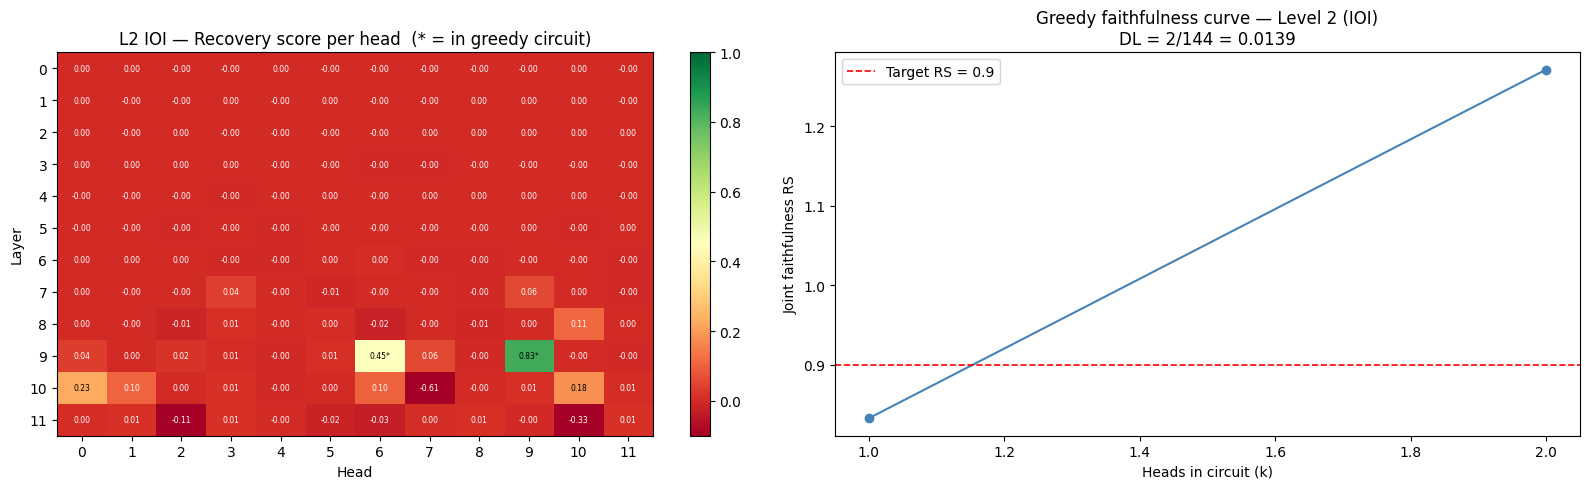

Plot saved -> ../results/level2IOI/level2IOI_recovery_scores.png


In [15]:
RS_TARGET = 0.90

# Sort heads by RS, keep positive
all_head_scores_sorted = sorted(head_scores.items(), key=lambda x: x[1], reverse=True)
(best_l, best_h), max_rs = all_head_scores_sorted[0]
pos_heads   = [(l, h) for (l, h), rs in all_head_scores_sorted if rs > 0]
total_heads = N_LAYERS * N_HEADS

print(f"Heads with positive RS : {len(pos_heads)} / {total_heads}")
print(f"Max individual RS      : {max_rs:.4f}  (L{best_l}H{best_h})")


def make_circuit_restore_hooks(circuit_heads, batch_fps, start_idx):
    batch_size = len(batch_fps)
    circuit_by_layer = {}
    for (l, h) in circuit_heads:
        circuit_by_layer.setdefault(l, []).append(h)
    hooks = []
    for layer in range(N_LAYERS):
        mean = mean_abc_acts[layer].to(device)
        hrs  = circuit_by_layer.get(layer, [])
        if not hrs:
            def make_abl(m=mean, fp=batch_fps):
                def hook_fn(value, hook):
                    bi = torch.arange(value.shape[0], device=value.device)
                    value[bi, fp] = m.unsqueeze(0).expand(value.shape[0], -1, -1)
                    return value
                return hook_fn
            hooks.append((RESULT_HOOK(layer), make_abl()))
        else:
            ca = {h: clean_head_acts[layer][start_idx:start_idx + batch_size, h, :].to(device)
                  for h in hrs}
            def make_partial(m=mean, fp=batch_fps, ca_=ca, hrs_=hrs):
                def hook_fn(value, hook):
                    bi = torch.arange(value.shape[0], device=value.device)
                    value[bi, fp] = m.unsqueeze(0).expand(value.shape[0], -1, -1)
                    for h in hrs_:
                        value[bi, fp, h] = ca_[h]
                    return value
                return hook_fn
            hooks.append((RESULT_HOOK(layer), make_partial()))
    return hooks


def run_faithfulness_heads(circuit_heads):
    buf = []
    for start in range(0, n_valid, BATCH_SIZE):
        end       = min(start + BATCH_SIZE, n_valid)
        batch_fps = final_positions[start:end]
        with torch.no_grad():
            logits = model.run_with_hooks(
                ioi_tokens[start:end],
                fwd_hooks=make_circuit_restore_hooks(circuit_heads, batch_fps, start)
            )
        buf.append(logit_diff(logits.cpu(), ioi_valid[start:end], batch_fps.cpu()))
        del logits
        torch.cuda.empty_cache()
    return recovery_score(torch.cat(buf), corrupted_ld, clean_ld)


# Greedy circuit construction
circuit_heads = []
faithfulness  = 0.0
rs_curve      = []

print(f"\nBuilding greedy circuit (target RS ≥ {RS_TARGET})...")
for k, (l, h) in enumerate(tqdm(pos_heads, desc="Greedy steps")):
    circuit_heads.append((l, h))
    faithfulness = run_faithfulness_heads(circuit_heads)
    rs_curve.append(faithfulness)
    print(f"  k={k+1:3d}  added L{l}H{h:2d}  RS={faithfulness:.4f}")
    if faithfulness >= RS_TARGET:
        break

n_circuit_heads    = len(circuit_heads)
description_length = n_circuit_heads / total_heads

print()
print("=" * 58)
print("  Level 2 — Attention heads — IOI task")
print("=" * 58)
print(f"  RS target            : {RS_TARGET}")
print(f"  Max individual RS    : {max_rs:.4f}")
print(f"  Criterion 1  Faithfulness RS    : {faithfulness:.4f}")
print(f"  Criterion 2  Description length : {description_length:.4f}")
print(f"               ({n_circuit_heads} / {total_heads} heads)")
print("=" * 58)

# Plots
rs_matrix   = np.array([[head_scores[(l, h)] for h in range(N_HEADS)] for l in range(N_LAYERS)])
circuit_set = set(circuit_heads)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

im = ax1.imshow(rs_matrix, cmap="RdYlGn", aspect="auto", vmin=-0.1, vmax=1.0)
ax1.set_xlabel("Head"); ax1.set_ylabel("Layer")
ax1.set_title("L2 IOI — Recovery score per head  (* = in greedy circuit)")
ax1.set_xticks(range(N_HEADS)); ax1.set_yticks(range(N_LAYERS))
plt.colorbar(im, ax=ax1)
for l in range(N_LAYERS):
    for h in range(N_HEADS):
        v = rs_matrix[l, h]
        marker = "*" if (l, h) in circuit_set else ""
        ax1.text(h, l, f"{v:.2f}{marker}", ha="center", va="center", fontsize=5.5,
                 color="black" if 0.15 < v < 0.85 else "white")

ax2.plot(range(1, len(rs_curve) + 1), rs_curve, "o-", color="steelblue",
         linewidth=1.5, markersize=6)
ax2.axhline(RS_TARGET, color="red", linestyle="--", linewidth=1.2,
            label=f"Target RS = {RS_TARGET}")
ax2.set_xlabel("Heads in circuit (k)")
ax2.set_ylabel("Joint faithfulness RS")
ax2.set_title(f"Greedy faithfulness curve — Level 2 (IOI)\n"
              f"DL = {n_circuit_heads}/{total_heads} = {description_length:.4f}")
ax2.legend()

plt.tight_layout()
out_plot = RESULTS_DIR / "level2IOI_recovery_scores.png"
plt.savefig(out_plot, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved -> {out_plot}")

In [16]:
results = {
    "level": 2,
    "task": "ioi",
    "method": "activation_patching_head_restoration",
    "n_examples": n_valid,
    "clean_ld": clean_ld.mean().item(),
    "corrupted_ld": corrupted_ld.mean().item(),
    "circuit_selection": "greedy_cumulative",
    "rs_target": RS_TARGET,
    "max_individual_rs": max_rs,
    "criterion1_faithfulness": faithfulness,
    "criterion2_description_length": description_length,
    "criterion2_circuit_heads": n_circuit_heads,
    "criterion2_total_heads": total_heads,
    "circuit_heads": [[l, h] for l, h in circuit_heads],
    "head_scores": {
        f"L{l}H{h}": head_scores[(l, h)]
        for l in range(N_LAYERS) for h in range(N_HEADS)
    },
}

out_json = RESULTS_DIR / "level2IOI_results.json"
with open(out_json, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved -> {out_json}")
print(f"\nSummary:")
print(f"  Criterion 1  Faithfulness RS    : {faithfulness:.4f}")
print(f"  Criterion 2  Description length : {description_length:.4f}")
print(f"               ({n_circuit_heads} / {total_heads} heads)")
print(f"  Circuit: {circuit_heads}")

Results saved -> ../results/level2IOI/level2IOI_results.json

Summary:
  Criterion 1  Faithfulness RS    : 1.2716
  Criterion 2  Description length : 0.0139
               (2 / 144 heads)
  Circuit: [(9, 9), (9, 6)]
